In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow  import keras
from keras.models import  Sequential
from keras.layers import Dense,Conv2D,Flatten,BatchNormalization,MaxPooling2D,Dropout


2026-05-09 11:29:19.462366: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-09 11:29:19.501994: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-09 11:29:19.502027: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-09 11:29:19.503499: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-09 11:29:19.511576: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    "data/train",
    target_size=(128,128),
    batch_size=16,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    "data/val",
    target_size=(128,128),
    batch_size=16,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    "data/test",
    target_size=(128,128),
    batch_size=16,
    class_mode='binary'
)

Found 17471 images belonging to 2 classes.
Found 4991 images belonging to 2 classes.
Found 2497 images belonging to 2 classes.


In [3]:
model = Sequential()

model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

2026-05-02 11:09:08.114257: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-02 11:09:08.230376: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-02 11:09:08.230458: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-02 11:09:08.231942: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-02 11:09:08.232010: I external/local_xla/xla/stream_executor

In [4]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 128, 128, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 64, 64, 64)        256       
 chNormalization)                                                
                                                        

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/5
1092/1092 [==============================] - 144s 131ms/step - loss: 0.6619 - accuracy: 0.5813 - val_loss: 0.5629 - val_accuracy: 0.6610
Epoch 2/5
1092/1092 [==============================] - 156s 143ms/step - loss: 0.6242 - accuracy: 0.6296 - val_loss: 0.5252 - val_accuracy: 0.7259
Epoch 3/5
1092/1092 [==============================] - 146s 133ms/step - loss: 0.5801 - accuracy: 0.6648 - val_loss: 0.5021 - val_accuracy: 0.7323
Epoch 4/5
1092/1092 [==============================] - 141s 129ms/step - loss: 0.5474 - accuracy: 0.6962 - val_loss: 0.5125 - val_accuracy: 0.7017
Epoch 5/5
1092/1092 [==============================] - 115s 105ms/step - loss: 0.5098 - accuracy: 0.7224 - val_loss: 0.4513 - val_accuracy: 0.7800


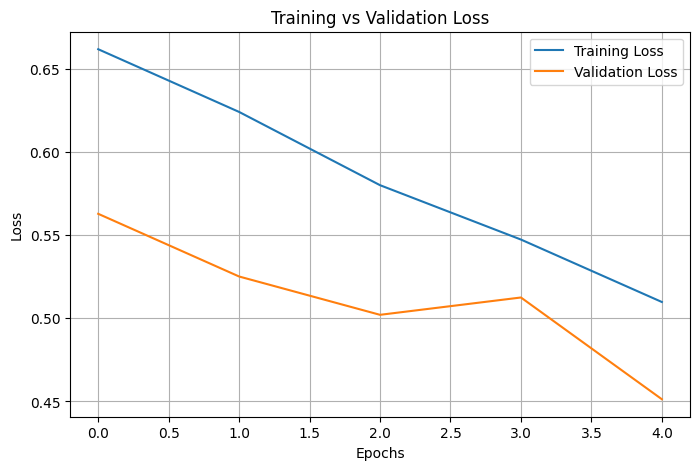

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8,5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

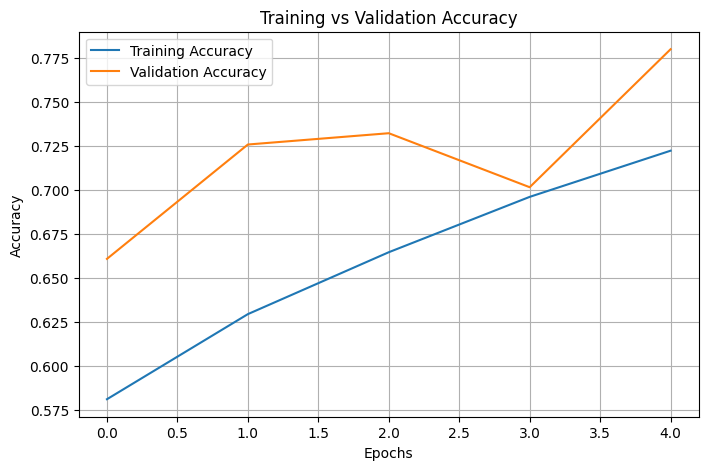

In [14]:
# Accuracy values
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(8,5))
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

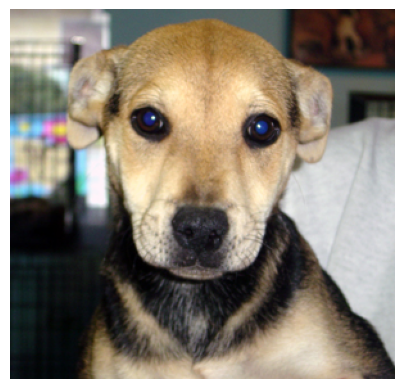

NameError: name 'model' is not defined

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('../data/test/Dog/4.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')  
plt.show()

img = cv2.resize(img, (128, 128))
img = img / 255.0   # 🔥 IMPORTANT
img = np.expand_dims(img, axis=0)

model.predict(img)
